In [ ]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
# -------------------------------------------------
# Create FrozenLake Environment
# -------------------------------------------------

# Write your code here
custom_map = [
    "FFSF",
    "FHFH",
    "FFFF",
    "GFHF"
]

env = gym.make(
    "FrozenLake-v1",
    desc=custom_map,
    is_slippery=True
)

print("Custom FrozenLake map:")
for row in custom_map:
    print(row)

print("\nStart state: custom position (0, 2)")
print("Goal state: custom position (3, 0)")





Custom FrozenLake map:
FFSF
FHFH
FFFF
GFHF

Start state: custom position (0, 2)
Goal state: custom position (3, 0)


In [ ]:
# -------------------------------------------------
# Hyperparameters
# -------------------------------------------------
num_episodes = 10000
max_steps_per_episode = 100

alpha = 0.001          # Learning rate
gamma = 0.99         # Discount factor

# CHANGED: Epsilon is controlled by a variable range
epsilon_start = 1.0
epsilon_min = 0.05
epsilon_decay = 0.9995

# Initial epsilon value is taken from epsilon_start
epsilon = epsilon_start


In [ ]:
# -------------------------------------------------
# Initialize Q-table
# -------------------------------------------------

# Write your code here
Q = np.zeros((env.observation_space.n, env.action_space.n))

# -------------------------------------------------
# Epsilon-Greedy Action Selection
# -------------------------------------------------

# Write your code here
def epsilon_greedy_action(state, epsilon):
    """
    Selects an action using epsilon-greedy strategy.
    Epsilon is passed as a variable, so its value can change
    during training instead of remaining fixed.
    """
    if np.random.random() < epsilon:
        return env.action_space.sample()
    return np.argmax(Q[state])


In [ ]:
# -------------------------------------------------
# Q-Learning Training
# -------------------------------------------------

# Write your code here



# -------------------------------------------------
# Q-Learning Training
# -------------------------------------------------

# Track rewards and states for evaluation later
episode_rewards = []
state_values = np.zeros(env.observation_space.n)
learned_policy = np.zeros(env.observation_space.n, dtype=int)

for episode in range(num_episodes):
    state, info = env.reset()
    total_reward = 0

    for step in range(max_steps_per_episode):
        # Select action using epsilon-greedy strategy
        action = epsilon_greedy_action(state, epsilon)

        # Take action in the environment
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        # Update Q-value using the Q-learning update rule
        best_next_action = np.argmax(Q[next_state])
        td_target = reward + gamma * Q[next_state][best_next_action] * (not done)
        td_error = td_target - Q[state][action]
        Q[state][action] += alpha * td_error

        total_reward += reward
        state = next_state

        if done:
            break

    # Decay epsilon
    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    episode_rewards.append(total_reward)

# Derive final state values and optimal policy from the Q-table
state_values = np.max(Q, axis=1)
learned_policy = np.argmax(Q, axis=1)



In [ ]:
# -------------------------------------------------
# Display Functions
# -------------------------------------------------

def print_value_function(values):
    print("\nEstimated State-Value Function:")
    print(np.round(values.reshape(4, 4), 3))


def print_policy(policy):
    action_symbols = {
        0: "L",
        1: "D",
        2: "R",
        3: "U"
    }

    policy_grid = np.array(
        [action_symbols[action] for action in policy]
    ).reshape(4, 4)

    print("\nLearned Policy:")
    print(policy_grid)


In [ ]:
# -------------------------------------------------
# Output
# -------------------------------------------------

print("\nFinal Q-table:")
print(np.round(Q, 3))

print_value_function(state_values)
print_policy(learned_policy)

average_reward = np.mean(episode_rewards[-1000:])
print("\nAverage reward over last 1000 episodes:", average_reward)


Final Q-table:
[[0.072 0.003 0.003 0.002]
 [0.023 0.001 0.    0.001]
 [0.    0.008 0.    0.   ]
 [0.    0.    0.    0.004]
 [0.005 0.004 0.113 0.001]
 [0.    0.    0.    0.   ]
 [0.    0.004 0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.047 0.409 0.022 0.006]
 [0.11  0.005 0.001 0.002]
 [0.001 0.001 0.    0.017]
 [0.    0.    0.    0.001]
 [0.    0.    0.    0.   ]
 [0.195 0.014 0.001 0.004]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]]

Estimated State-Value Function:
[[0.072 0.023 0.008 0.004]
 [0.113 0.    0.004 0.   ]
 [0.409 0.11  0.017 0.001]
 [0.    0.195 0.    0.   ]]

Learned Policy:
[['L' 'L' 'D' 'U']
 ['R' 'L' 'D' 'L']
 ['D' 'L' 'U' 'U']
 ['L' 'L' 'L' 'L']]

Average reward over last 1000 episodes: 0.126


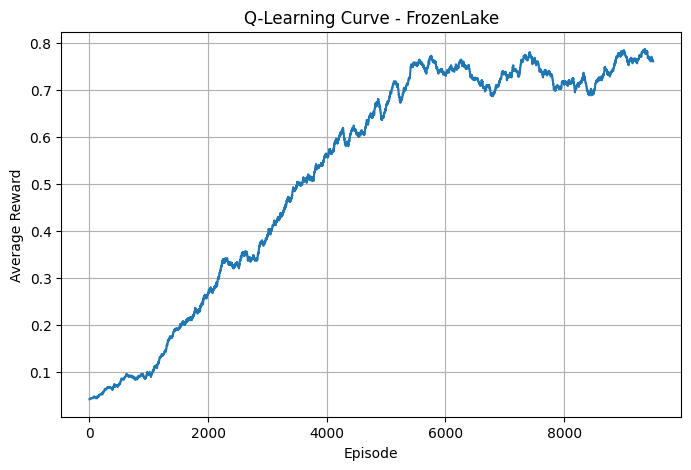

In [ ]:
# -------------------------------------------------
# Plot Learning Curve
# -------------------------------------------------

window = 500

moving_average = np.convolve(
    episode_rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(8, 5))
plt.plot(moving_average)
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("Q-Learning Curve - FrozenLake")
plt.grid(True)
plt.show()

env.close()